## 1. Load and inspect the data

In [73]:
# pandas for tables, numpy for numeric helpers
import pandas as pd
import numpy as np


In [74]:
# load the titanic csv (it must sit in the same folder as this notebook)
# first look: head = sample rows, describe = summary stats, shape = (rows, cols), columns = names
df=pd.read_csv("Titanic-Dataset.csv")

print(df.head())
print(df.describe())
print(df.shape)
print(df.columns)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [75]:
# info shows each column's dtype and non-null count (age, cabin and embarked have gaps)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [76]:
# count missing values per column; this decides what to drop and what to fill
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 2. Clean the data (missing values)

In [77]:
# cabin is mostly missing, so drop the whole column
# age is numeric, so fill with the median (robust to outliers)
# embarked is categorical, so fill with the mode (most frequent port)
# re-check that no nulls remain
df=df.drop("Cabin",axis=1)
df["Age"]=df["Age"].fillna(df["Age"].median())
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [78]:
# count duplicate rows; if above 0, remove them with df.drop_duplicates()
print(df.duplicated().sum())

0


## 3. Look at the target

In [79]:
# class distribution of the target: roughly 62% did not survive, 38% survived (mildly imbalanced)
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


<Axes: xlabel='Survived'>

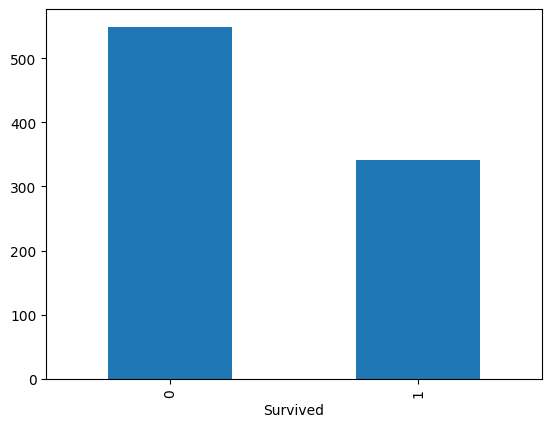

In [80]:
# bar chart of the same class counts
df["Survived"].value_counts().plot(kind='bar')

## 4. Feature engineering and encoding

In [81]:
# feature engineering: family size = siblings/spouses + parents/children + the passenger themself
df['family_size']=df["SibSp"]+df["Parch"]+1

In [82]:
# models need numbers, so encode sex (male=0, female=1); a simple map is enough for a binary column
df['Sex']=df['Sex'].map({"male":0 , "female":1})
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare Embarked  family_size  
0         A/5 21171   7.2500        S            2  
1          PC 17599  71.2833        C            2  
2  STON/O2. 3101282   7.9250        S            1  
3            113803  53.1000        S            2  
4            373450   8.0500   

In [83]:
# confirm the exact column names before choosing features
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'family_size'],
      dtype='str')


## 5. Features, target and train/test split

In [84]:
# x = chosen features, y = target (1 = survived)
# name, ticket and passengerid are identifiers or free text, so they are left out
x=df[['Pclass','Sex','Age','Fare','family_size']]
y=df['Survived']

In [85]:
# 80/20 split; stratify=y keeps the survived ratio the same in train and test
# random_state makes the split reproducible; the test set stays unseen until final evaluation
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

DECISION TREE

In [86]:
# criterion='entropy' = split by information gain; max_depth=3 limits the tree to reduce overfitting
# fit learns the split rules from the training data, predict applies them to the test set
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

model.fit(x_train,y_train)

pred=model.predict(x_test)

**Logic: decision tree.** The tree asks yes/no questions on features (for example `Sex <= 0.5`) and at each step picks the question that makes the two resulting groups purest. Purity is measured by entropy here, and the drop in entropy is the information gain. `max_depth=3` stops it from memorising the training data.

In [87]:
# accuracy = correct predictions / all predictions
# confusion matrix: rows = actual, columns = predicted, layout [[TN, FP], [FN, TP]]
# the report gives precision, recall and f1 per class
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print('accuracy: ',accuracy_score(y_test,pred))

print('confusion matrix: ')
print(confusion_matrix(y_test,pred))

print('classification report: ')
print(classification_report(y_test,pred))

accuracy:  0.8044692737430168
confusion matrix: 
[[99 11]
 [24 45]]
classification report: 
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.65      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



In [88]:
# precision for class 1 (survived) = TP / (TP + FP)
# of everyone predicted as a survivor, how many really survived
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    pred
)
print(precision)

0.8035714285714286


In [89]:
# ravel flattens the 2x2 matrix into tn, fp, fn, tp
# specificity = TN / (TN + FP) = share of actual non-survivors correctly identified
tn, fp, fn, tp = confusion_matrix(
    y_test,
    pred
).ravel()

#of all the actual negatives how many correctly identified
specificity = tn / (tn + fp)

print("Specificity:", specificity)

Specificity: 0.9


In [90]:
# roc_auc needs probabilities, not labels: [:, 1] = probability of class 1
# auc = chance a random survivor is ranked above a random non-survivor (0.5 = random, 1 = perfect)
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(x_test)[:, 1]
auc=roc_auc_score(
    y_test,
    y_prob
)

print('roc_auc: ',auc)

roc_auc:  0.827536231884058


In [91]:
# average precision = area under the precision-recall curve
# more informative than roc_auc when classes are imbalanced
from sklearn.metrics import average_precision_score

ap = average_precision_score(
    y_test,
    y_prob
)

print("Average Precision:", ap)

Average Precision: 0.7619376304688814


In [92]:
# overfitting check: close train and test accuracy = good generalisation, a large gap = overfitting
print("Train accuracy:", model.score(x_train, y_train))
print("Test accuracy:", model.score(x_test, y_test))

Train accuracy: 0.8286516853932584
Test accuracy: 0.8044692737430168


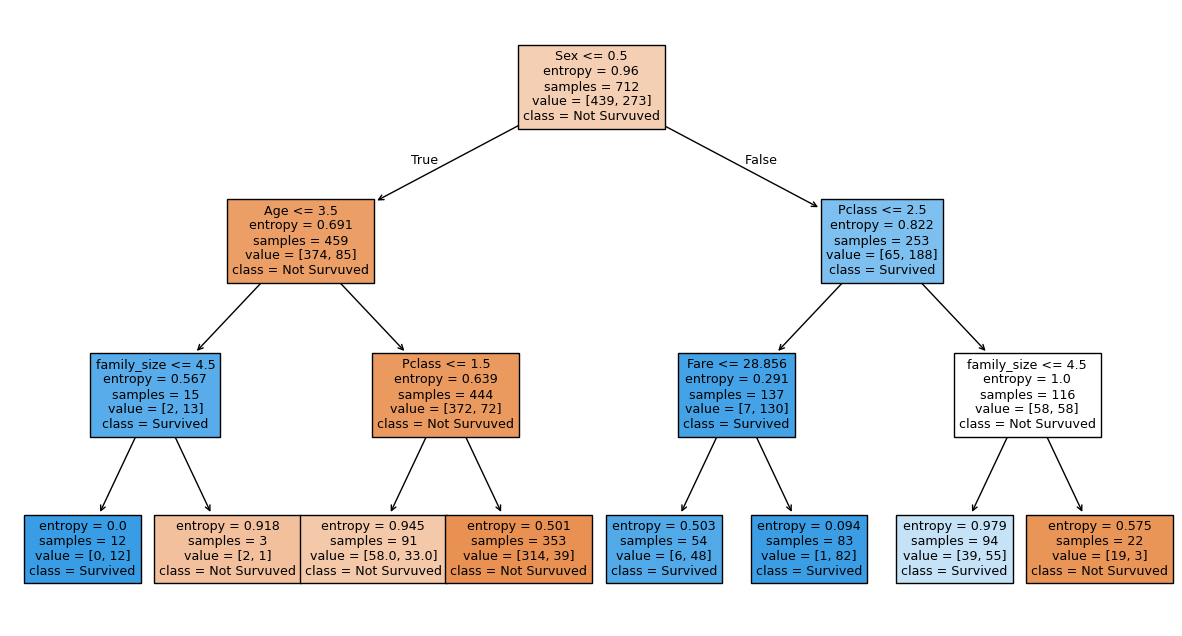

In [93]:
# draw the fitted tree: each box shows the split rule, entropy, samples and class counts
# colour = majority class in that node
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=['Not Survuved','Survived'],
    filled=True

)

plt.show()

### Cross-validation (training data only)

In [94]:
# 5-fold cv on the training data only: train on 4 parts, validate on 1, repeat 5 times
# mean = expected accuracy, std = how stable it is; shuffle=True avoids order bias
from sklearn.model_selection import(
    KFold,
    cross_val_score
)

kf=KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores=cross_val_score(
    model,
    x_train,
    y_train,
    cv=kf,
    scoring='accuracy'
)

print('fold scores: ',scores)
print('mean: ',scores.mean())
print('std: ',scores.std())

fold scores:  [0.7972028  0.81818182 0.8028169  0.82394366 0.88732394]
mean:  0.8258938244853737
std:  0.03222625371443019


In [95]:
# stratified 5-fold keeps the class ratio in every fold
# scored with f1 here, so these numbers are lower than the accuracy scores above
from sklearn.model_selection import StratifiedKFold

skf=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores=cross_val_score(
    model,
    x_train,
    y_train,
    cv=skf,
    scoring='f1'
)

print("Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

Scores: [0.75925926 0.68085106 0.7311828  0.73076923 0.74509804]
Mean: 0.7294320777545776
Std: 0.026457705911435713


In [96]:
# leave-one-out: n folds with a single validation row each (712 evaluations = one per training row)
# low bias but slow and high variance, so only practical on small data
from sklearn.model_selection import(
    LeaveOneOut,
    cross_val_score
)

loo=LeaveOneOut()

scores=cross_val_score(
    model,
    x_train,
    y_train,
    cv=loo
)

print("Number of evaluations:", len(scores))
print("Mean score:", round(scores.mean(), 3))

Number of evaluations: 712
Mean score: 0.822


In [97]:
# repeated k-fold: 5-fold run 3 times with different shuffles = 15 scores, a more stable estimate
from sklearn.model_selection import RepeatedKFold

rkf=RepeatedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

scores = cross_val_score(
    model,
    x_train,
    y_train,
    cv=rkf,
    scoring="accuracy"
)

print("Number of evaluations:", len(scores))
print("Mean accuracy:", round(scores.mean(), 3))
print("Standard deviation:", round(scores.std(), 3))

Number of evaluations: 15
Mean accuracy: 0.813
Standard deviation: 0.03


### Save predictions

In [98]:
# save actual vs predicted labels for the test set
# index=False stops pandas writing the row index as an extra column
output=pd.DataFrame({
    'actual':y_test,
    'predicted':pred
})

output.to_csv('titanicpred.csv',index=False)

print(output.head())

     actual  predicted
565       0          0
160       0          0
553       1          0
860       0          0
241       1          1


In [99]:
# refit on the full training set (cross_val_score trains clones, so this is not strictly needed)
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [100]:
# predictions again (same as pred above)
y_pred = model.predict(x_test)

In [101]:
# same train vs test accuracy check as before
print("Train accuracy:", model.score(x_train, y_train))
print("Test accuracy:", model.score(x_test, y_test))

Train accuracy: 0.8286516853932584
Test accuracy: 0.8044692737430168


RANDOM FOREST 

In [102]:
# n_estimators=100 trees, each trained on a bootstrap sample of the rows
# max_depth=5 and min_samples_split=4 limit tree size
# max_features='sqrt' = each split looks at a random subset of features, which decorrelates the trees
# final prediction = majority vote of all trees
from sklearn.ensemble import RandomForestClassifier

modelrf=RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=4,
    max_features='sqrt',
    random_state=42
)

modelrf.fit(x_train,y_train)
predrf=modelrf.predict(x_test)


**Logic: random forest.** Many trees are trained in parallel, each on a random bootstrap sample of rows and a random subset of features at each split. Predictions are combined by majority vote. Averaging trees that make different mistakes lowers variance, so the forest overfits less than one deep tree.

In [103]:
# accuracy and per-class metrics for the forest
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,predrf)

print('accuracy: ',accuracy)

print(classification_report(y_test,predrf))

accuracy:  0.7821229050279329
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       110
           1       0.77      0.62      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78      0.78      0.78       179



In [104]:
# overfitting check for the forest
print("Train accuracy:", modelrf.score(x_train, y_train))
print("Test accuracy:", modelrf.score(x_test, y_test))

Train accuracy: 0.8637640449438202
Test accuracy: 0.7821229050279329


In [105]:
# feature importance = how much each feature reduced impurity across all trees (normalised to sum to 1)
# sorted from most to least important
importance=pd.Series(
    modelrf.feature_importances_,
    index=x.columns
)

importance=importance.sort_values(ascending=False)

print(importance)

Sex            0.458144
Fare           0.195076
Pclass         0.136189
Age            0.126906
family_size    0.083685
dtype: float64


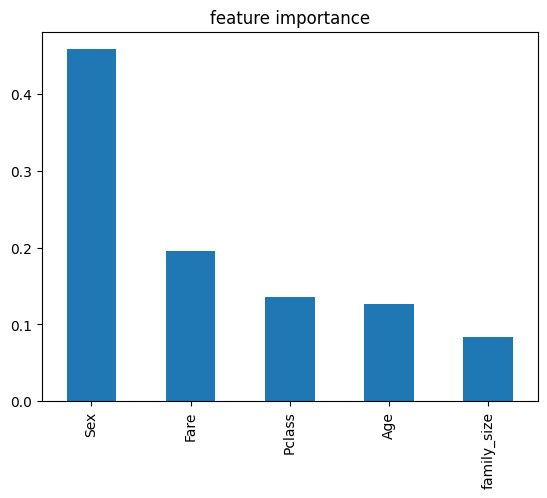

In [106]:
# bar chart of the feature importances
importance.plot(kind='bar')
plt.title('feature importance')
plt.show()

## Gradient boosting

**Logic: gradient boosting.** Trees are built one after another. Each new shallow tree is fitted to the errors (residuals) of the model so far, and its output is scaled by `learning_rate` before being added. Boosting mainly reduces bias, and many small steps usually beat a few big ones.

In [107]:
# trees are built one after another, each fitted to the errors left by the previous trees
# learning_rate=0.05 shrinks each tree's contribution (small rate = needs enough trees)
# max_depth=3 keeps each tree a weak, shallow learner
from sklearn.ensemble import GradientBoostingClassifier

gb=GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(x_train,y_train)

gbpred=gb.predict(x_test)

In [108]:
# accuracy and per-class metrics for gradient boosting
print(
    'accuracy of gradient boosting',
    accuracy_score(y_test,gbpred)
)

print(
    'classification_report',
    classification_report(y_test,gbpred)
)

accuracy of gradient boosting 0.7988826815642458
classification_report               precision    recall  f1-score   support

           0       0.78      0.94      0.85       110
           1       0.85      0.58      0.69        69

    accuracy                           0.80       179
   macro avg       0.82      0.76      0.77       179
weighted avg       0.81      0.80      0.79       179



In [109]:
# overfitting check for gradient boosting
print("Train accuracy:", gb.score(x_train, y_train))
print("Test accuracy:", gb.score(x_test, y_test))

Train accuracy: 0.8693820224719101
Test accuracy: 0.7988826815642458


In [110]:
# install xgboost into this environment (-q = quiet output)
!pip -q install xgboost

## XGBoost

**Logic: XGBoost.** It is gradient boosting with extras: L1/L2 regularisation on the leaf weights, second-order gradient information, row sampling (`subsample`) and column sampling (`colsample_bytree`), and native handling of missing values. It is usually more accurate and faster than plain gradient boosting.

In [111]:
# optimised gradient boosting with built-in regularisation
# subsample=0.8 = each tree sees 80% of the rows; colsample_bytree=0.8 = 80% of the features
# both add randomness to reduce overfitting; eval_metric='logloss' = the loss it reports
from xgboost import XGBClassifier

xgb=XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)


xgb.fit(x_train,y_train)
xgbpred=xgb.predict(x_test)

In [112]:
# accuracy and per-class metrics for xgboost
print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, xgbpred)
)

print(
    classification_report(
        y_test,
        xgbpred
    )
)

XGBoost Accuracy: 0.7877094972067039
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       110
           1       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



In [113]:
# overfitting check for xgboost
print("Train accuracy:", xgb.score(x_train, y_train))
print("Test accuracy:", xgb.score(x_test, y_test))

Train accuracy: 0.9073033707865169
Test accuracy: 0.7877094972067039


In [114]:
# install lightgbm into this environment (-q = quiet output)
!pip -q install lightgbm

## LightGBM

**Logic: LightGBM.** It is also boosting, but grows trees leaf-wise: it always splits the leaf with the biggest loss reduction instead of growing level by level. This is faster and often more accurate, but can overfit small data, so `num_leaves` is the key knob.

In [ ]:
# leaf-wise tree growth; num_leaves=31 is the main complexity control, max_depth=-1 = no depth limit
# note: in lightgbm, subsample only has an effect when subsample_freq is above 0, so subsample=0.8 is ignored here
# verbosity=-1 silences the training logs
from lightgbm import LGBMClassifier

lgbm=LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgbm.fit(x_train,y_train)
lgbmpred=lgbm.predict(x_test)

# n_estimators       → number of trees
# learning_rate      → contribution of each tree
# num_leaves         → complexity of each tree
# max_depth          → maximum tree depth
# subsample          → percentage of rows used
# colsample_bytree   → percentage of features used
# random_state       → reproducible results
# verbosity          → controls output/messages

In [116]:
# accuracy and per-class metrics for lightgbm
print('lgbm accuracy: ',accuracy_score(y_test,lgbmpred))

print(classification_report(y_test,lgbmpred))

lgbm accuracy:  0.7877094972067039
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       110
           1       0.73      0.71      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



In [117]:
# overfitting check for lightgbm
print("Train accuracy:", lgbm.score(x_train, y_train))
print("Test accuracy:", lgbm.score(x_test, y_test))

Train accuracy: 0.9382022471910112
Test accuracy: 0.7877094972067039


## Summary of results (test set, 179 rows)

| model | train accuracy | test accuracy | recall (survived) |
|---|---|---|---|
| decision tree (depth 3) | 0.829 | 0.804 | 0.65 |
| random forest | 0.864 | 0.782 | 0.62 |
| gradient boosting | 0.869 | 0.799 | 0.58 |
| xgboost | 0.907 | 0.788 | 0.67 |
| lightgbm | 0.938 | 0.788 | 0.71 |

**Reading the table:** all five models land within about 2 points of each other on test accuracy, and with only 179 test rows one passenger is worth about 0.6 points, so the differences are mostly noise. The gap between train and test grows from the simple tree (0.025) to lightgbm (0.150), which shows the more flexible models overfit this small dataset. If catching survivors matters most, lightgbm has the best recall (0.71), while the depth-3 tree gives the best accuracy with the simplest model.